#### N tools called ⇒ N+1 model calls

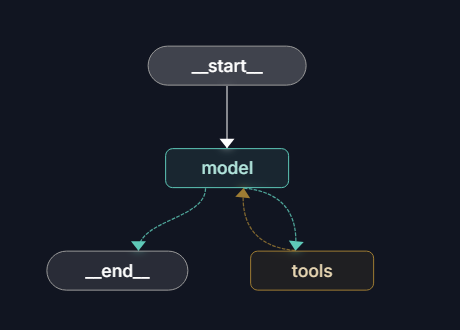

#### import libraries

In [4]:
from dotenv import load_dotenv

load_dotenv()

True

#### Create the tool

 — avilyClient wrapped by @tool

```py
from langchain.tools import tool
from typing import Dict, Any
from tavily import TavilyClient

tavily_client = TavilyClient()

@tool
def web_search(query: str) -> Dict[str, Any]:

    """Search the web for information"""

    return tavily_client.search(query)
```

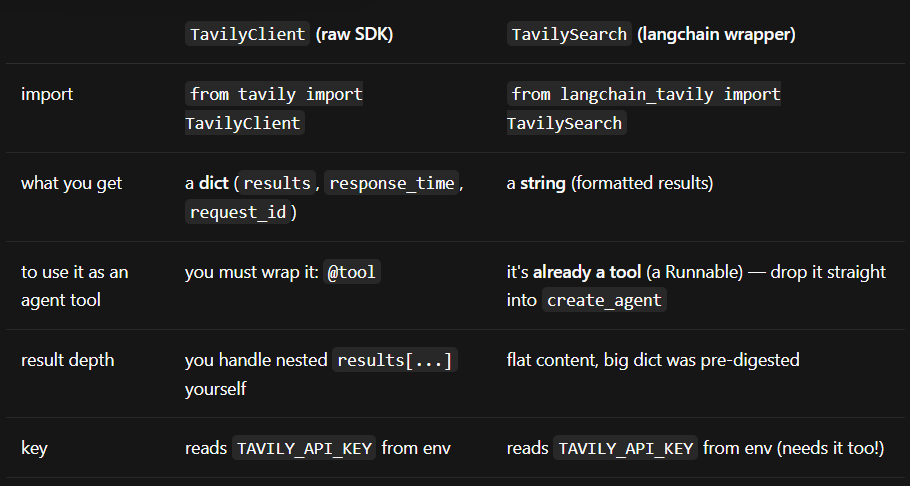

In [16]:
#ready-made: TavilySearch
from langchain_tavily import TavilySearch

web_search = TavilySearch(k=5)
web_search.invoke("what can i make with leftover chicken and rice?")


Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://eu.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://eu.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


{'query': 'what can i make with leftover chicken and rice?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.reddit.com/r/recipes/comments/4dsvy6/what_can_i_make_with_already_cooked_chicken_and',
   'title': 'What can I make with already cooked chicken and rice? - Reddit',
   'content': "Our subreddit\n\n_I am a bot, and this action was performed automatically. Please__contact the moderators of this subreddit__if you have any questions or concerns._\n\n, and stir to combine. Let cook over medium - low heat for half an hour so flavors combine. Serve over rice with vegetables on the side.\n\nImage 14: u/nrcuisine avatar\n\nSemigourmet\n\n•11y ago\n\nalso the leftover chicken can be used to make yourself a tortilla pizza.  \n\nImage 15: u/nrcuisine avatar\n\nnrcuisine\n\n•11y ago [...] •11y ago\n\nTry this Syrian recipe, tastes great every time and will consume your leftover rice, chicken and vegetables too \n\nImage 16: u/AlternativeBadger2

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://eu.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://eu.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


#### Create the model and system prompt

In [8]:
from langchain.chat_models import init_chat_model
import os

model = init_chat_model(
    model="gemini-3.1-flash-lite",
    model_provider="google-genai",
    api_key=os.getenv("GOOGLE_API_KEY"),
)
system_prompt = """

You are a personal chef. The user will give you a list of ingredients they have left over in their house.

Using the web search tool, search the web for recipes that can be made with the ingredients they have.

Return recipe suggestions and eventually the recipe instructions to the user, if requested.

he can even give u images or ingredients in that case do the same thing 

"""

#### Building the agent 

In [9]:
import os
from langchain.chat_models import init_chat_model
from langchain.agents import create_agent
from langgraph.checkpoint.memory import InMemorySaver



agent = create_agent(
    model=model,
    tools=[web_search],
    system_prompt=system_prompt,
    checkpointer=InMemorySaver()
)

#### Human message

In [10]:
from langchain.messages import HumanMessage

config = {"configurable": {"thread_id": "1"}}

response = agent.invoke(
    {"messages": [HumanMessage(content="I have some leftover chicken and rice. What can I make?")]},
    config
)

print(response['messages'][-1].content)

Failed to multipart ingest runs: langsmith.utils.LangSmithError: Failed to POST https://eu.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://eu.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://eu.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://eu.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://eu.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://eu.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://eu.api.smith.langchain.com/runs/multipart in LangSmith

[{'type': 'text', 'text': 'Leftover chicken and rice is a fantastic base for so many quick, delicious meals! Since the hard work (cooking the protein and the grain) is already done, you can have a fresh meal on the table in minutes.\n\nHere are my top three recommendations:\n\n### 1. Chicken Fried Rice (The Quickest Option)\nThis is the ultimate "clean-out-the-fridge" meal. It works best if your rice is cold from the fridge.\n*   **How to make it:** Heat a splash of oil in a pan. Add the chicken and some frozen veggies (peas, carrots, or corn work great). Once hot, add your rice. Toss in soy sauce, a little sesame oil, and garlic powder. Push the rice to one side, scramble an egg in the empty space, then mix everything together until crispy and hot.\n\n### 2. Cheesy Chicken & Rice Casserole (The Comfort Option)\nIf you want something warm and filling, this is the way to go.\n*   **How to make it:** In a bowl, mix your chicken and rice with a can of condensed soup (like cream of chicken

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://eu.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://eu.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


In [11]:
from pprint import pprint

pprint(response)

{'messages': [HumanMessage(content='I have some leftover chicken and rice. What can I make?', additional_kwargs={}, response_metadata={}, id='9fb23899-fffd-4d2d-a1f4-264b3791e221'),
              AIMessage(content=[], additional_kwargs={'function_call': {'name': 'tavily_search', 'arguments': '{"query": "easy recipes with leftover chicken and rice"}'}, '__gemini_function_call_thought_signatures__': {'call_1374663': 'EnEKbwFpFH0T2wSl0oR8MCEu0TfaXASApnml5RLzS2yrxkw5xy6kGDSlImcGePnXZBmNp32bWRDzQGaghAfcBr3Uc18/kGWK2GTxCg/RjL4fgYGdrOCzsYJFboZuVZwQw1hSbuP5cGXQjFH7CUMXEpKlPA=='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a0bf85-8d46-7ff1-b871-af58be8e4d21-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'easy recipes with leftover chicken and rice'}, 'id': 'call_1374663', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 1584, 'output_tokens': 

In [14]:
response = agent.invoke(
    {"messages": [HumanMessage(content="suggest some recipes plz about my last question?")]},
    config
)

print(response['messages'][-1].content)

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://eu.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://eu.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


[{'type': 'text', 'text': 'Since you are looking for specific recipe ideas using your leftover chicken and rice, here are three easy, distinct paths you can take depending on what else you have in your pantry.\n\nChoose the one that sounds most delicious to you, and **I will provide the full, step-by-step instructions for it!**\n\n---\n\n### Option 1: "Better Than Takeout" Fried Rice\nThis is the classic way to use up leftover rice. It’s savory, fast, and very forgiving.\n*   **Best if you have:** Soy sauce, an egg, garlic/onion, and any frozen or fresh vegetables (like peas, carrots, or broccoli).\n*   **The Vibe:** Salty, savory, and satisfying.\n\n### Option 2: Cheesy Chicken & Rice Casserole\nThis turns simple ingredients into a warm, creamy, comfort-food meal.\n*   **Best if you have:** A can of cream soup (mushroom, chicken, or celery), some shredded cheese, and perhaps some breadcrumbs or crushed crackers for the top.\n*   **The Vibe:** Gooey, cheesy, and hearty.\n\n### Option 3

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://eu.api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://eu.api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


In [15]:
pprint(response)

{'messages': [HumanMessage(content='I have some leftover chicken and rice. What can I make?', additional_kwargs={}, response_metadata={}, id='9fb23899-fffd-4d2d-a1f4-264b3791e221'),
              AIMessage(content=[], additional_kwargs={'function_call': {'name': 'tavily_search', 'arguments': '{"query": "easy recipes with leftover chicken and rice"}'}, '__gemini_function_call_thought_signatures__': {'call_1374663': 'EnEKbwFpFH0T2wSl0oR8MCEu0TfaXASApnml5RLzS2yrxkw5xy6kGDSlImcGePnXZBmNp32bWRDzQGaghAfcBr3Uc18/kGWK2GTxCg/RjL4fgYGdrOCzsYJFboZuVZwQw1hSbuP5cGXQjFH7CUMXEpKlPA=='}}, response_metadata={'finish_reason': 'STOP', 'model_name': 'gemini-3.1-flash-lite', 'safety_ratings': [], 'model_provider': 'google_genai'}, id='lc_run--01a0bf85-8d46-7ff1-b871-af58be8e4d21-0', tool_calls=[{'name': 'tavily_search', 'args': {'query': 'easy recipes with leftover chicken and rice'}, 'id': 'call_1374663', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 1584, 'output_tokens': 